In [ ]:
from astropy.table import Table
import numpy as np
import matplotlib as mpl
from superbit_lensing.utils import ClusterShearCorrelation, RhoStats
import os
from superbit_lensing.em5 import *

BASE_PATH = "/n23data1/saha/simulated_data/sim_utils/emp_psfs"

In [2]:
# -------------------------
# Matplotlib defaults
# -------------------------
mpl.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 400,
    "axes.labelsize": 17,
    "axes.titlesize": 17,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "legend.title_fontsize": 13,
    "legend.handlelength": 1.2,
    "lines.linewidth": 2.2,
    "lines.markersize": 6,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    'font.family': 'serif'
})


In [ ]:
summary_table_file = os.path.join(BASE_PATH, "psf_summary_table.fits")
tbl = Table.read(summary_table_file)
tbl = tbl[tbl["does_exist"]]
tbl = tbl[tbl["n_good_stars"] > 500]

diag_dir = os.path.join(BASE_PATH, 'emp_psfs_all', 'em5_diags_output')

# full paths to diag files
diag_files = [os.path.join(diag_dir, f) for f in tbl["em_diag_file"]]

# keep only rows whose diag file exists
diag_exists = [os.path.exists(f) for f in diag_files]
tbl = tbl[diag_exists]

# optionally keep the full path as a new column
tbl["diag_file_full"] = [os.path.join(diag_dir, f) for f in tbl["em_diag_file"]]

# sort by std_fwhm (smallest first)
tbl.sort("std_fwhm")

half_len = len(tbl)//2
#tbl = tbl[:half_len]

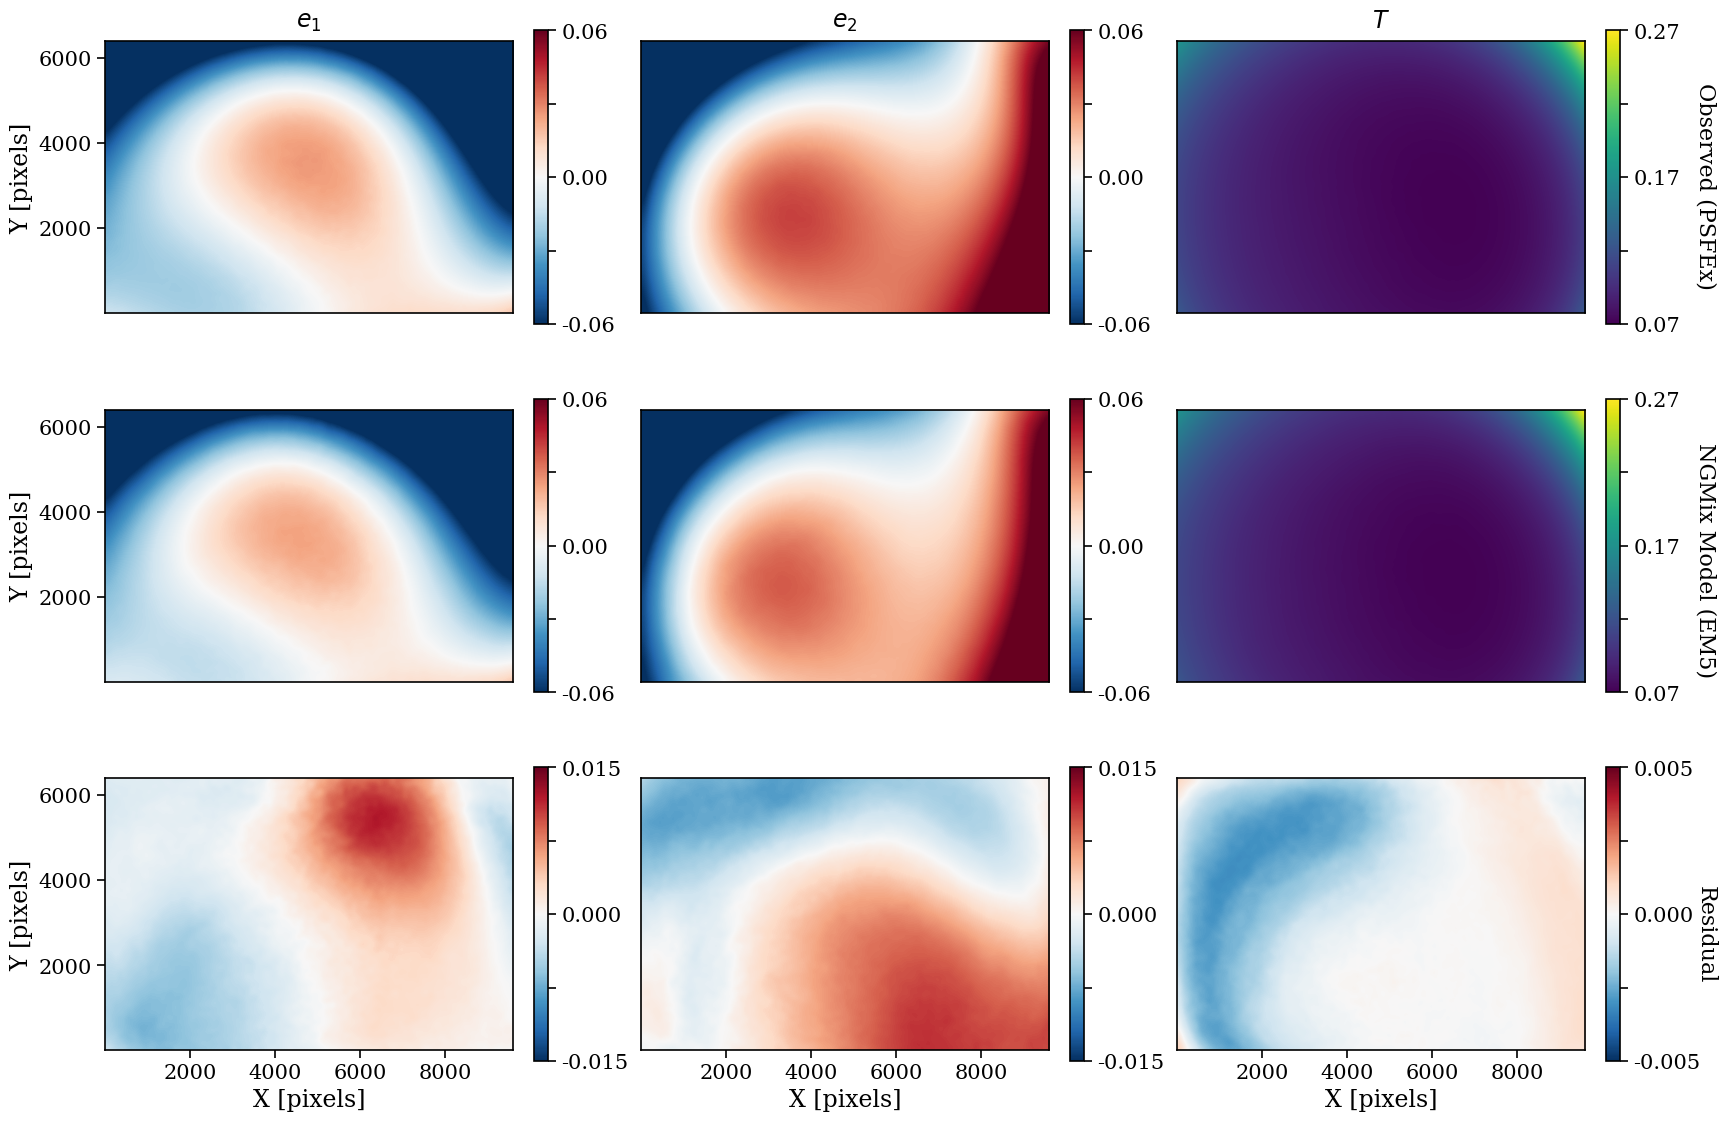

In [40]:
selected_diag_files = list(tbl["diag_file_full"])
coll = EM5PsfexMapCollection.load_many(selected_diag_files)
fig, axes = coll.plot_mean(show=True)
mega_table = coll.to_table()
#fig.savefig("mean_psf_properties_em5_one_panel.pdf", bbox_inches="tight")

In [29]:
COLUMN_CONFIG = {
    # Filter columns
    'set_column': 'SET',
    'flux_column': 'FLUX_AUTO',
    
    # Position columns
    'x_column': 'x',
    'y_column': 'y',
    
    # Observed shape columns
    'e1_obs': 'e1',
    'e2_obs': 'e2',
    'T_obs': 'T',
    
    # Model shape columns
    'e1_model': 'e1_em',
    'e2_model': 'e2_em',
    'T_model': 'T_em'
}


RHO_STATS_CONFIG = {
    'catalog_file': "/n23data1/saha/simulated_data/sim_utils/emp_psfs/stacked_annular_combined.fits",
    'M500': 6.31e14,      # Msun/h
    'z_cluster': 0.246,
    'z_min_offset': 0.05,
    'pixel_scale': 0.1408
}

rho = RhoStats(mega_table, COLUMN_CONFIG, pixel_scale=RHO_STATS_CONFIG['pixel_scale'])

analyzer = ClusterShearCorrelation(
    catalog_file=RHO_STATS_CONFIG['catalog_file'],
    M500=RHO_STATS_CONFIG['M500'],
    z_cluster=RHO_STATS_CONFIG['z_cluster']
)

corr = analyzer.run_analysis(z_min_offset=RHO_STATS_CONFIG['z_min_offset'])

fig, axs = rho.plot(safezone_corr=corr, fraction=0.1)
fig.savefig("rho_stats_treecorr_ngmixem5.pdf", dpi=600, bbox_inches="tight")

Running analysis for cluster at z=0.246
--------------------------------------------------
M500c = 6.31e+14 Msun/h, c500 = 1.96
M200c = 9.68e+14 Msun/h, c200 = 3.06
Selected 246222 background galaxies out of 276105 total
Computed correlation for 246222 galaxies


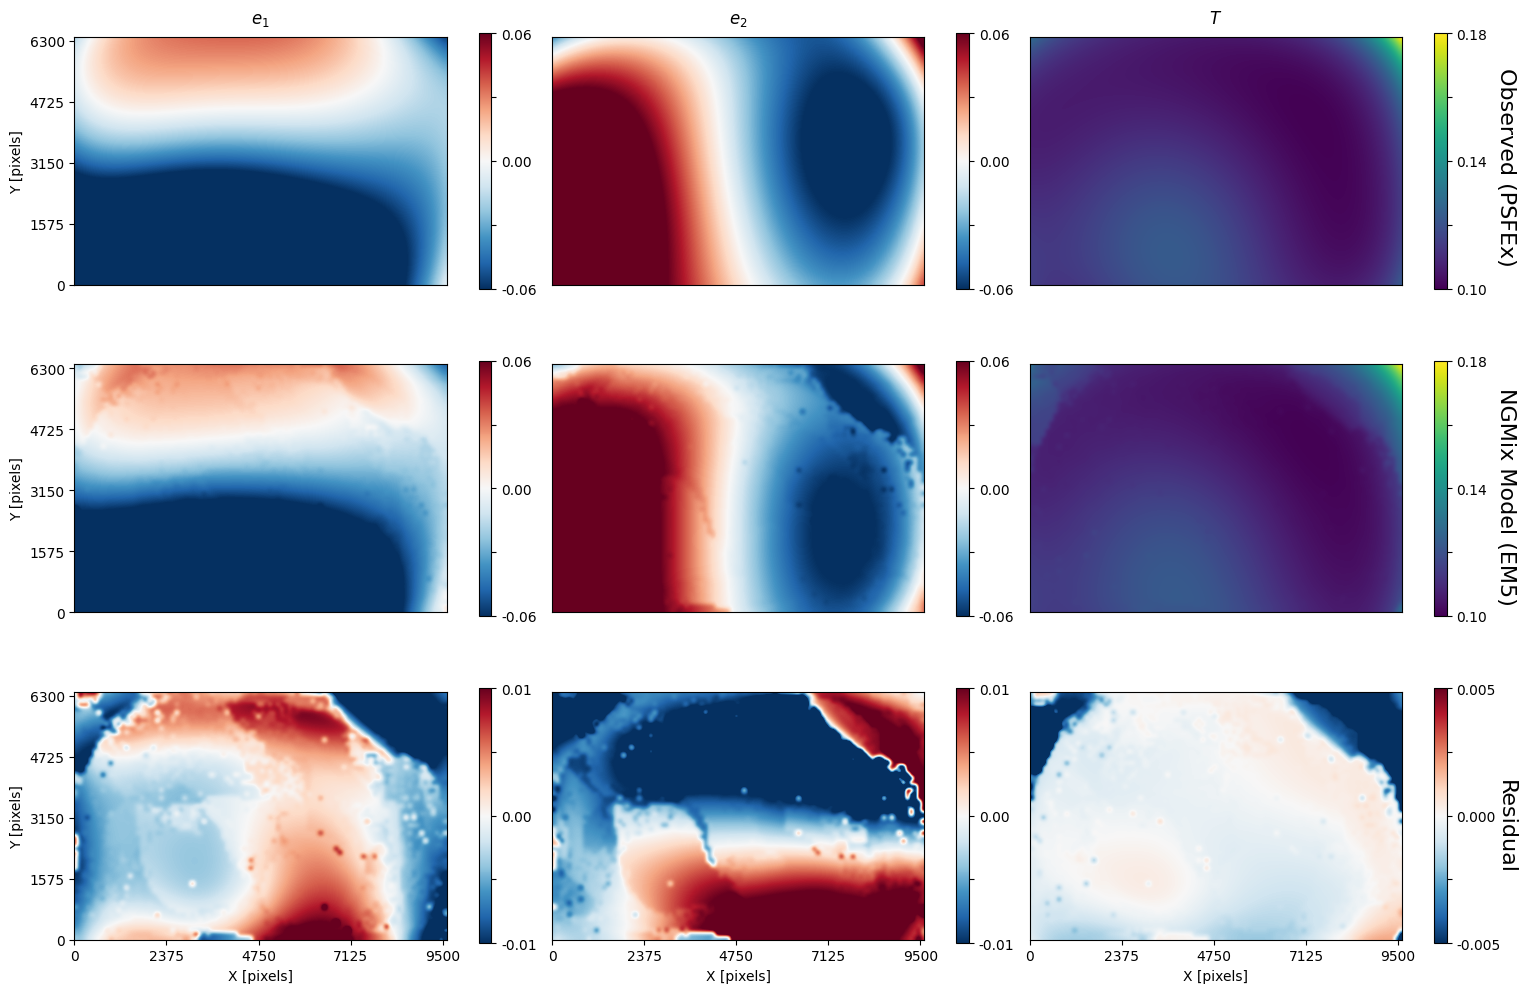

In [117]:
m = EM5PsfexMaps.from_npz(selected_diag_files[0])
_, _ = plot_em5_psfex_maps(m)